In [1]:
from scipy.optimize import fsolve
import numpy as np, matplotlib.pyplot as plt, pickle
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

from scipy.stats import norm, multivariate_normal
from scipy.integrate import solve_bvp
import warnings
from joblib import Parallel, delayed
from tqdm.auto import tqdm  # nice progress bars
from pathlib import Path
from scipy.optimize import newton_krylov
from scipy.sparse import diags


c:\ProgramData\anaconda3\envs\RIC\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Classical Impulse Control Problem for Cash Management

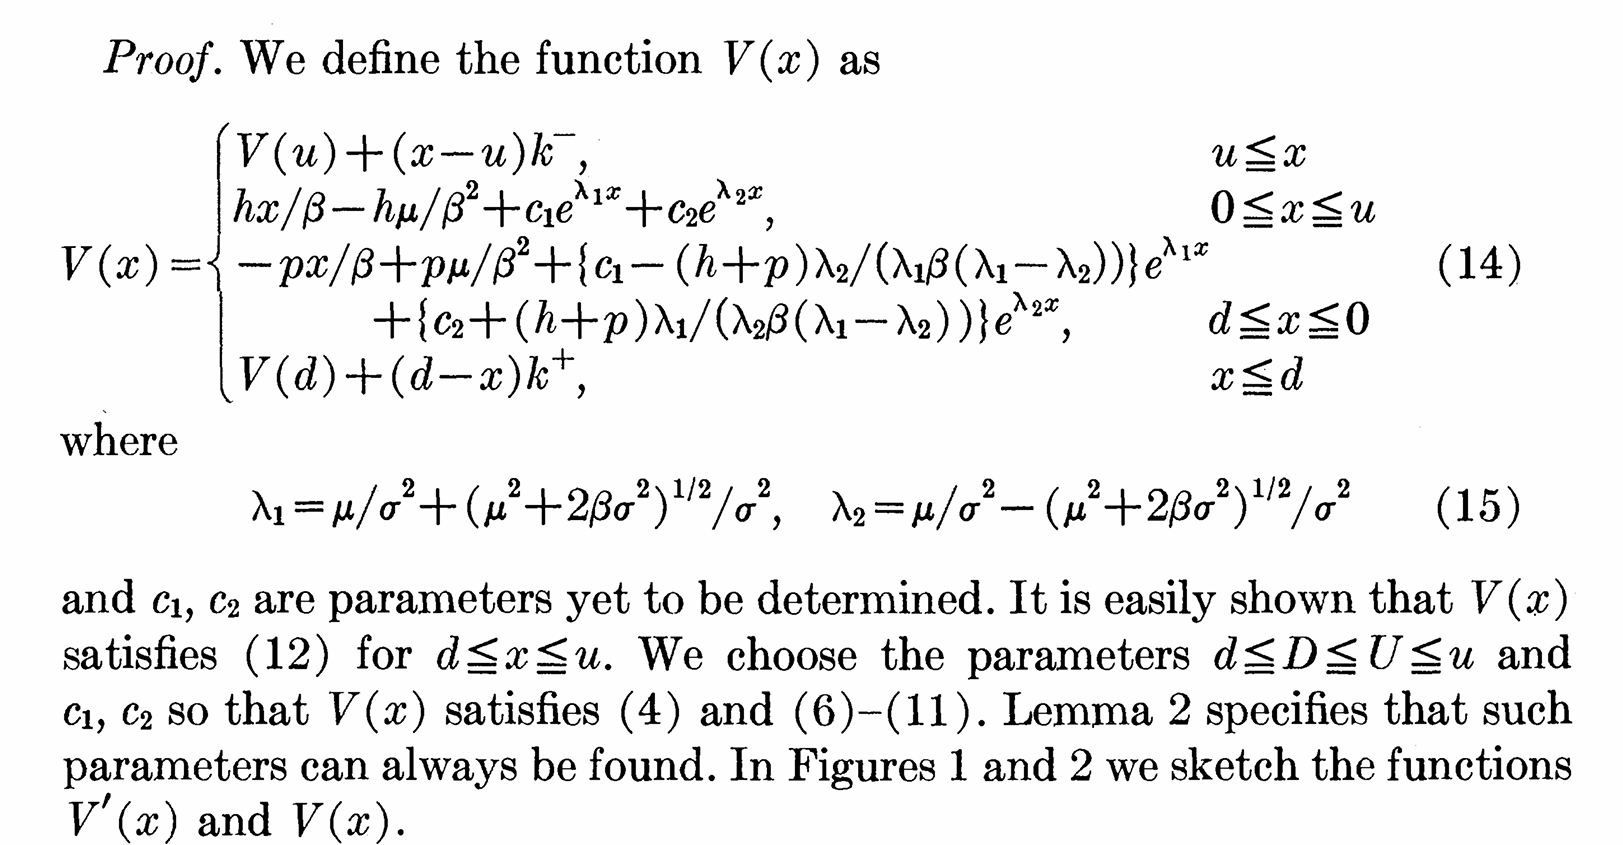
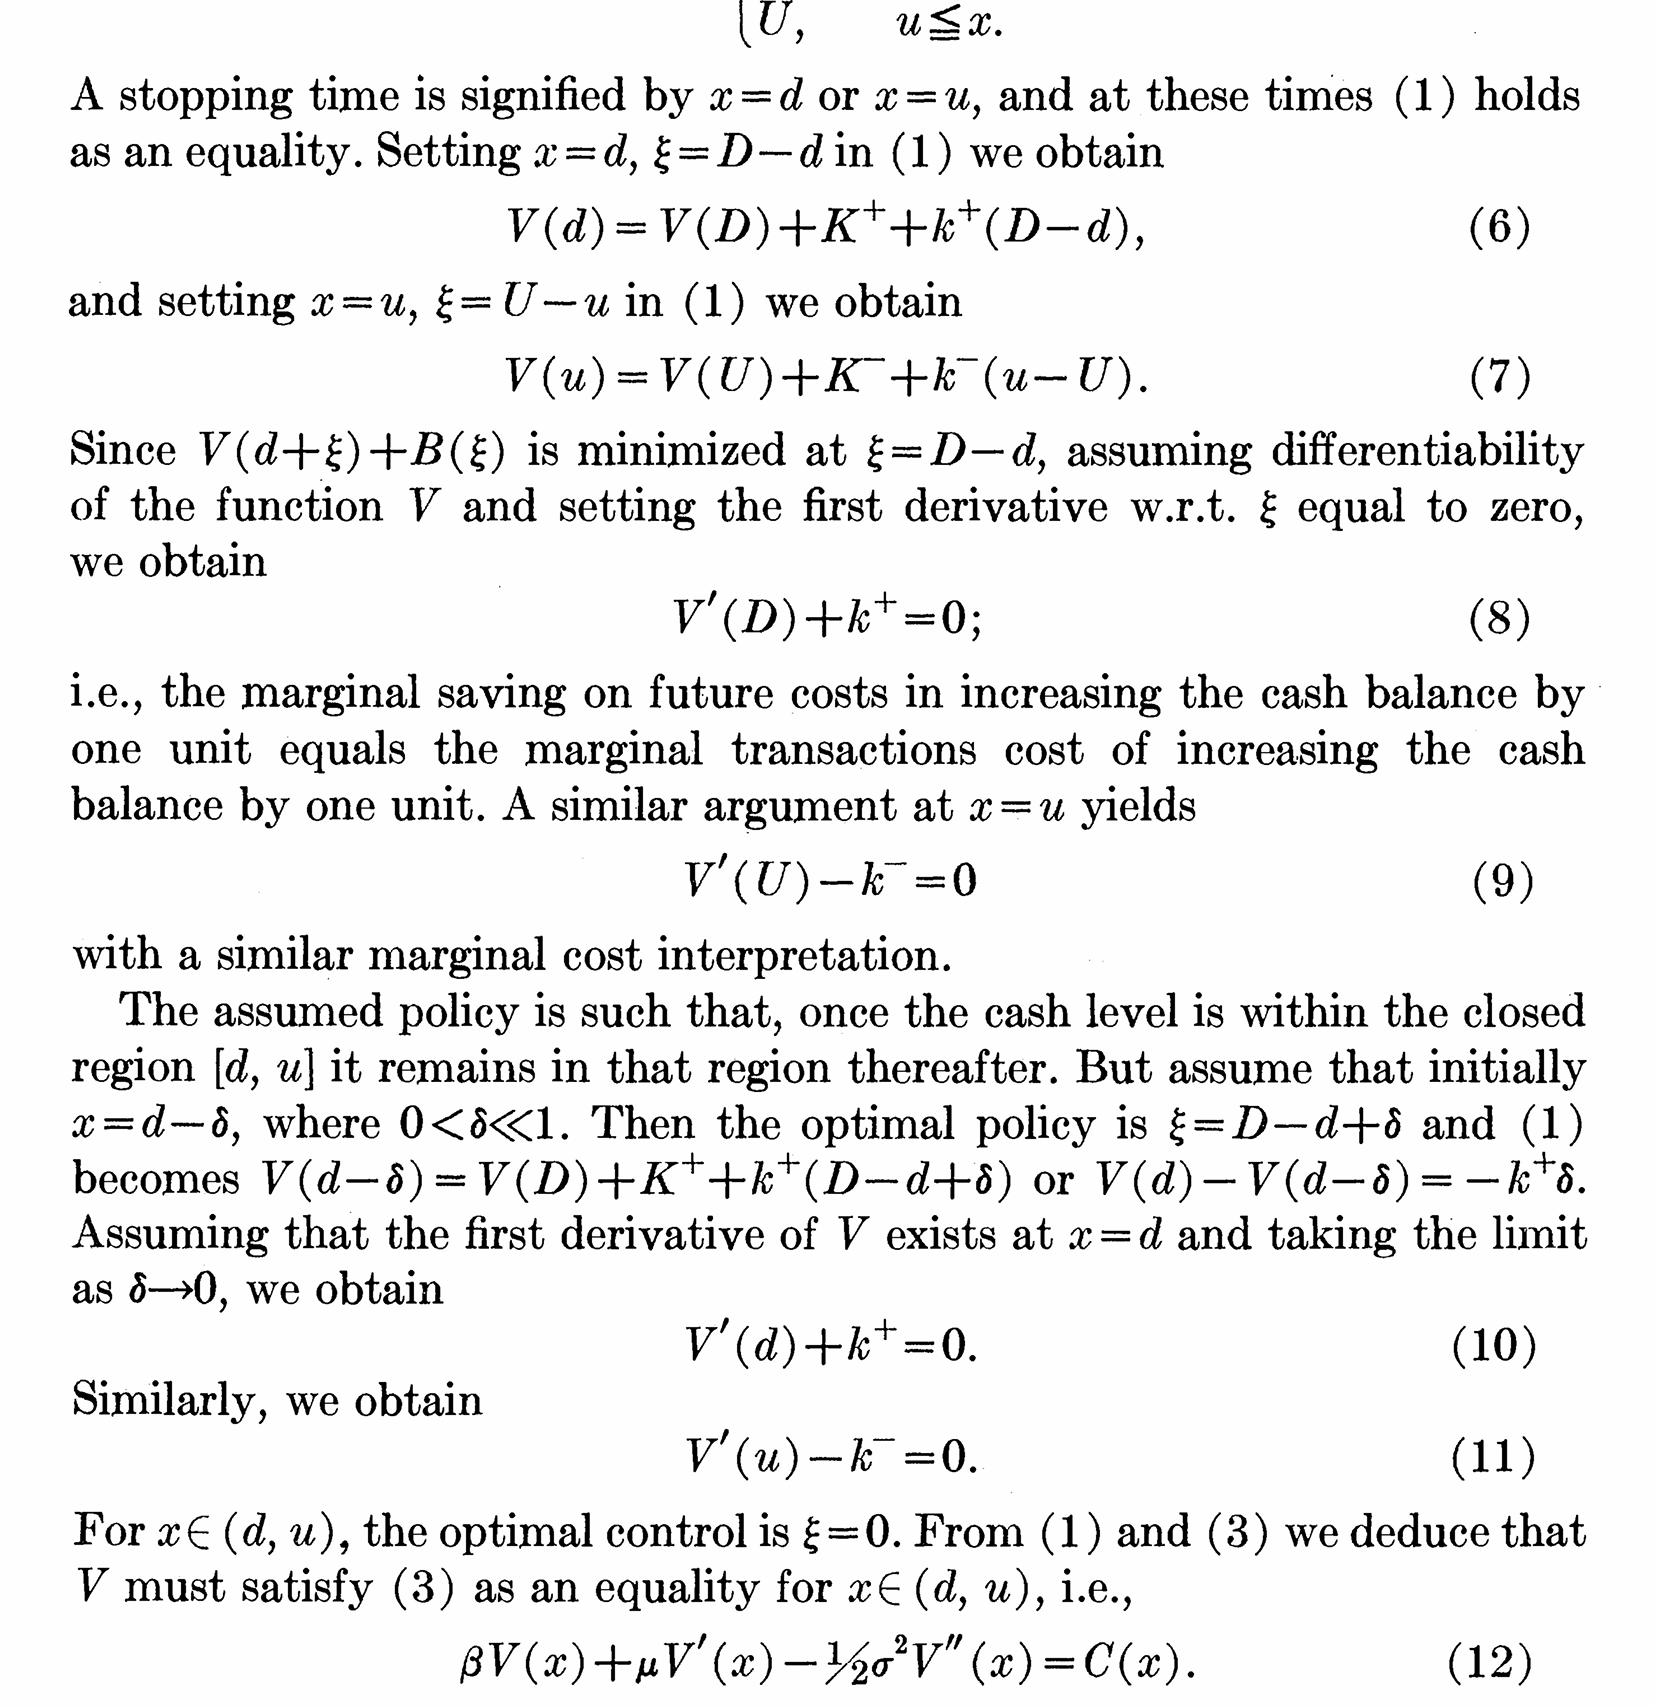

We solve $c_1$, $c_2$ in (14) that satisfies (6)-(11).
<!-- Assume we know the solution structure, solve for the the boundary of action and continuation regions and the corresponding solution on each region.

Recall that the running cost is defined as
$$
f(x) = \begin{cases}
h\,x, & x\ge0,\$$1mm]
-p\,x, & x<0.
\end{cases}
$$

In the continuation region, the value function $u(x)$ satisfies
$$
\frac{1}{2}\sigma^2\,x^2\,u''(x)+\mu\,x\,u'(x)-r\,u(x)+f(x)=0.
$$

Because $f(x)$ is piecewise defined, the *particular solution* to the nonhomogeneous ODE will differ depending on whether $x\ge0$ or $x<0$. In fact:

- **For $x\ge0$:**  
  A natural guess is $u_p(x)= C_+\,x$. Plugging into the ODE (with $f(x)=h\,x$) yields
  $$
  \mu\,C_+\,x - r\,C_+\,x + h\,x = \bigl[(\mu-r)C_+ + h\bigr]x = 0,
  $$
  so that
  $$
  C_+ = \frac{h}{r-\mu}.
  $$
  Thus, for $x\ge0$ the particular solution is
  $$
  u_p(x)= \frac{h}{r-\mu}\,x.
  $$

- **For $x<0$:**  
  Similarly, guess $u_p(x)= C_-\,x$. Now, with $f(x)=-p\,x$ we have
  $$
  \mu\,C_-\,x - r\,C_-\,x - p\,x = \bigl[(\mu-r)C_- - p\bigr]x = 0,
  $$
  so that
  $$
  C_- = \frac{p}{r-\mu}.
  $$
  Hence, for $x<0$ the particular solution is
  $$
  u_p(x)= -\frac{p}{r-\mu}\,x.
  $$

The general solution to the homogeneous part of the ODE is the same for both regions and is given by
$$
u_{\text{hom}}(x)= A\,x^{m_1}+B\,x^{m_2},
$$
where $m_1$ and $m_2$ are the roots of
$$
\frac{1}{2}\sigma^2\,m(m-1)+\mu\,m-r=0.
$$

Thus, the full solution in the continuation region is *piecewise* defined as
$$
u(x)=
\begin{cases}
A_+\,x^{m_1}+B_+\,x^{m_2}+\displaystyle\frac{h}{r-\mu}\,x, & x\ge0,\$$2mm]
A_-\,x^{m_1}+B_-\,x^{m_2}-\displaystyle\frac{p}{r-\mu}\,x, & x<0.
\end{cases}
$$

In our code example we assumed that the continuation region lies entirely in $x\ge0$, so that we could use the solution
$$
u(x)=A\,x^{m_1}+B\,x^{m_2}+\frac{h}{r-\mu}\,x,
$$
and set the free-boundary conditions accordingly. 

If the continuation region spans both negative and positive values (i.e. if the lower intervention boundary $q$ is negative), then one needs to solve for two sets of constants $(A_-,B_-)$ and $(A_+,B_+)$ and enforce additional matching conditions at $x=0$ (continuity and smoothness) in order to fully incorporate the piecewise definition of $f(x)$.



In [4]:

import numpy as np
from scipy.optimize import fsolve

r, mu, sigma = 0.50, 0.00, 1.00
h, p = 1.0, 1.0
Kp, kp, Km, km = 3.0, 1.0, 3.0, 1.0

disc = mu**2 + 2*r*sigma**2
t1 = (-mu + np.sqrt(disc))/sigma**2
t2 = (-mu - np.sqrt(disc))/sigma**2
print(f"t1 = {t1:.4f},   t2 = {t2:.4f}")

def V_pos(x,c1,c2):
    return  h*x/r + mu*h/r**2 + c1*np.exp(t1*x)+c2*np.exp(t2*x)
def V_pos_p(x,c1,c2):
    return  h/r + c1*t1*np.exp(t1*x)+c2*t2*np.exp(t2*x)
def coeff_neg(c1,c2):
    A=(h+p)/r; B=(h+p)*mu/r**2
    C1 = c1 - A*t2/(t1*(t1-t2))
    C2 = c2 + A*t1/(t2*(t1-t2))
    return C1,C2
def V_neg(x,c1,c2):
    C1,C2 = coeff_neg(c1,c2)
    return -p*x/r - mu*p/r**2 + C1*np.exp(t1*x)+C2*np.exp(t2*x)
def V_neg_p(x,c1,c2):
    C1,C2 = coeff_neg(c1,c2)
    return -p/r + C1*t1*np.exp(t1*x)+C2*t2*np.exp(t2*x)

def F(X):
    c1,c2,d,D,u,U = X
    return [
        V_neg_p(d,c1,c2)  + kp,
        V_neg_p(D,c1,c2)  + kp,
        V_neg(d,c1,c2) - (V_neg(D,c1,c2)+Kp+kp*(D-d)),
        V_pos_p(u,c1,c2) - km,
        V_pos_p(U,c1,c2) - km,
        V_pos(u,c1,c2) - (V_pos(U,c1,c2)+Km+km*(u-U))
    ]

# Current initial guess
e3 = np.exp(Km/km)
a_q, b_q, c_q = e3, -2*(e3+1), 1
disc_q = b_q**2 - 4*a_q*c_q
v = (-b_q + np.sqrt(disc_q)) / (2*a_q)
U0 = np.log(v); u0 = U0 + Km/km
c1_0 = -2 / (np.exp(u0 + U0) + 1); c2_0 = c1_0 + 2

x0 = [c1_0, c2_0, -u0, -U0, u0, U0]
print(f"\nInitial guess: c1={c1_0:.6f}, c2={c2_0:.6f}, d={-u0:.4f}, D={-U0:.4f}, u={u0:.4f}, U={U0:.4f}")
print(f"Residual at x0: {F(x0)}")

sol, info, ier, msg = fsolve(F, x0, full_output=True)
print(f"\nfsolve flag: {ier}  ({msg})")
print(f"Solution: c1={sol[0]:.6f}, c2={sol[1]:.6f}, d={sol[2]:.4f}, D={sol[3]:.4f}, u={sol[4]:.4f}, U={sol[5]:.4f}")
print(f"Residual at sol: {F(sol.tolist())}")


t1 = 1.0000,   t2 = -1.0000

Initial guess: c1=-0.022849, c2=1.977151, d=-3.7302, D=-0.7302, u=3.7302, U=0.7302
Residual at x0: [np.float64(-2.220446049250313e-15), np.float64(0.0), np.float64(-1.8102965072897304), np.float64(2.220446049250313e-16), np.float64(0.0), np.float64(-1.8102965072897321)]

fsolve flag: 1  (The solution converged.)
Solution: c1=-0.003421, c2=1.996579, d=-5.6708, D=-0.6983, u=5.6708, U=0.6983
Residual at sol: [np.float64(-1.6457168960926083e-10), np.float64(5.503364430836655e-10), np.float64(1.5917045459445944e-10), np.float64(-1.4761553090991697e-09), np.float64(-5.486403553689456e-10), np.float64(-1.4834586892220614e-09)]


d=-5.671, D=-0.698, u=5.671, U=0.698, c1=-0.003421, c2=1.996579
Saved classical_V.pkl


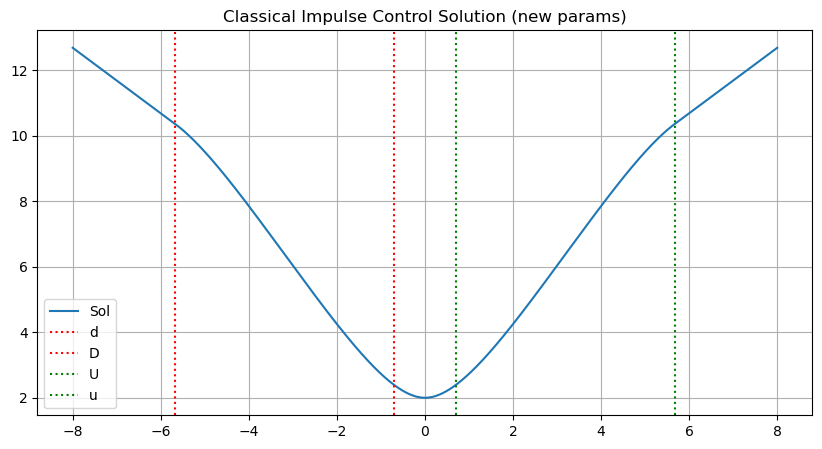

In [6]:

import pickle, matplotlib.pyplot as plt

c1, c2, d, D, u, U = sol
print(f"d={d:.3f}, D={D:.3f}, u={u:.3f}, U={U:.3f}, c1={c1:.6f}, c2={c2:.6f}")

with open('classical_V.pkl', 'wb') as f:
    pickle.dump((c1,c2,d,D,u,U), f)
print("Saved classical_V.pkl")

def V(x):
    if x<=d:   return V_neg(d,c1,c2)+kp*(d-x)
    if x<=0:   return V_neg(x,c1,c2)
    if x<=u:   return V_pos(x,c1,c2)
    return V_pos(u,c1,c2)+km*(x-u)

xp = np.linspace(-8,8,10001)
plt.figure(figsize=(10,5))
plt.plot(xp,[V(x) for x in xp],label='Sol'); plt.grid()
for x, lab, c in zip([d,D,U,u], ['d','D','U','u'], ['r','r','g','g']):
    plt.axvline(x, color=c, linestyle=':', label=lab)
plt.legend()
plt.title("Classical Impulse Control Solution (new params)"); plt.show()
